# Automatsko sumiranje tekstova na srpskom jeziku korišćenjem velikih jezičkih modela

## 01. Uvod i cilj projekta

Automatsko sumiranje teksta je dobro proučeno za engleski jezik, ali su resursi i prethodno obučeni modeli za srpski mnogo oskudniji: jezik je morfološki bogat (mnogo oblika reči po lemi), piše se na **dva pisma** (ćirilicom i latinicom) naizmenično, i ne postoji široko korišćen, veliki, ljudski anotirani skup podataka za sumiranje na srpskom jeziku.

**Cilj ovog projekta:** izgraditi i uporediti tri porodice automatskih rezimirača na malom korpusu srpskih veb stranica:

1. **Extractive** — TextRank, algoritam zasnovan na grafovima, bez nadzora, koji bira postojeće rečenice iz izvornog teksta.
2. **Transformer (abstractive, fine-tuned seq2seq)** — višejezični model sekvence po sekvenci (`csebuetnlp/mT5_multilingual_XLSum`) fino podešen posebno za sumiranje i pokrivanje srpskog među 45 jezika.
3. **LLM-based (abstractive, prompted)** — LLM opšte namene prilagođen instrukcijama
   (`llama3.1:8b`, lokalno putem **Ollama**) navedeno na srpskom da se napravi kratak rezime.

Tri pristupa se zatim procenjuju istim metrikama, statistički upoređuju i analiziraju kako se ponašaju kako se dužina izvornog teksta menja, koliko su brzi i gde ne uspevaju.

**Dataset.** Korpus je izgrađen od **raznih veb stranica** (članaca na srpskoj Vikipediji koji obuhvataju nekoliko tema/domena). Za svaku stranicu tretiramo **uvodni pasus** kao ljudski napisan rezime referenci, a **ostatak članka** kao tekst koji treba rezimirati — ista konstrukcija koju koriste dobro poznati skupovi podataka za rezimiranje u stilu WikiSum-a. Ovo daje pravi, slobodno dostupan rezime referenci za svaki dokument bez ikakvih ručnih napomena.


## 02. Libraries

In [1]:
import re
import time
import warnings
import textwrap
from urllib.parse import urlparse, unquote
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import requests
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats
from itertools import combinations

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RNG = np.random.default_rng(42)

%matplotlib inline

In [2]:
try:
    from rouge_score import rouge_scorer
    HAVE_ROUGE = True
except ImportError:
    HAVE_ROUGE = False
    print("[warn] rouge-score not installed -> pip install rouge-score")

try:
    import torch  # noqa: F401
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
    HAVE_TORCH = True
except Exception as exc:
    HAVE_TORCH = False
    print(f"[warn] PyTorch/transformers not fully available in this environment ({exc}) "
          "-> the Transformer section will use its fallback path.")

try:
    import ollama
    HAVE_OLLAMA_LIB = True
except ImportError:
    HAVE_OLLAMA_LIB = False
    print("[warn] ollama python client not installed -> pip install ollama")

print("Libraries ready.")
print(f"HAVE_ROUGE={HAVE_ROUGE}  HAVE_TORCH={HAVE_TORCH}  HAVE_OLLAMA_LIB={HAVE_OLLAMA_LIB}")

Libraries ready.
HAVE_ROUGE=True  HAVE_TORCH=True  HAVE_OLLAMA_LIB=True


## 03. Učitavanje skupa podataka

Za svaku stranicu:
* **prvi pasus** pre naslova prvog odeljka se stavlja po strani kao
**rezime reference**,
* sve ostalo postaje **izvorni tekst** koji će naše tri metode sumirati.

In [3]:
DATASET_URLS = [
    "https://sr.wikipedia.org/wiki/%D0%92%D0%B5%D1%88%D1%82%D0%B0%D1%87%D0%BA%D0%B0_%D0%B8%D0%BD%D1%82%D0%B5%D0%BB%D0%B8%D0%B3%D0%B5%D0%BD%D1%86%D0%B8%D1%98%D0%B0", # vestacka inteligencija
    "https://sr.wikipedia.org/wiki/%D0%9D%D0%B8%D0%BA%D0%BE%D0%BB%D0%B0_%D0%A2%D0%B5%D1%81%D0%BB%D0%B0", # tesla
    "https://sr.wikipedia.org/wiki/%D0%A1%D1%80%D0%B1%D0%B8%D1%98%D0%B0", # srbija
    "https://sr.wikipedia.org/wiki/%D0%98%D0%BD%D1%82%D0%B5%D1%80%D0%BD%D0%B5%D1%82", # internet
    "https://sr.wikipedia.org/wiki/%D0%9D%D0%B8%D1%88" # nis
]

# --- Wikimedia requires a descriptive User-Agent identifying the client and a way to contact its operator.
CONTACT_INFO = "stefanstojiljkovic5@gmail.com"
HEADERS = {
    "User-Agent": (
        f"SerbianSummarizationProject/1.0 {CONTACT_INFO} "
        f"python-requests/{requests.__version__}"
    )
}

REQUEST_DELAY_SEC = 1.0  

def _api_get_with_retry(api_url, params, timeout=10, max_retries=4):
    last_exc = None
    for attempt in range(max_retries):
        try:
            resp = requests.get(api_url, headers=HEADERS, params=params, timeout=timeout)
        except requests.exceptions.RequestException as exc:
            last_exc = exc
            break
        if resp.status_code in (403, 429):
            wait = REQUEST_DELAY_SEC * (2 ** attempt)
            print(f"[rate limited] HTTP {resp.status_code} on {api_url} "
                  f"-> retrying in {wait:.1f}s (attempt {attempt + 1}/{max_retries})")
            time.sleep(wait)
            continue
        resp.raise_for_status()
        return resp
    if last_exc is not None:
        raise last_exc
    resp.raise_for_status()
    return resp

def scrape_wikipedia_sr(url, timeout=10):
    '''Fetch a Serbian Wikipedia article via the MediaWiki Action API and split it
    into (title, reference, body).

    reference = lead paragraph(s) before the first section heading
    body      = the remaining paragraphs (this is what gets summarized)
    '''
    parsed = urlparse(url)
    page_title = unquote(parsed.path.rsplit("/", 1)[-1])
    api_url = f"https://{parsed.netloc}/w/api.php"
    params = {
        "action": "parse",
        "page": page_title,
        "prop": "text",
        "format": "json",
        "formatversion": 2,
        "redirects": 1,
    }

    resp = _api_get_with_retry(api_url, params, timeout=timeout)
    data = resp.json()
    if "error" in data:
        raise ValueError(data["error"].get("info", "unknown MediaWiki API error"))

    title = data["parse"]["title"]
    soup = BeautifulSoup(data["parse"]["text"], "html.parser")

    lead_paras, body_paras = [], []
    in_lead = True
    for el in soup.find_all(["p", "h2", "h3"]):
        if el.name in ("h2", "h3"):
            in_lead = False
            continue
        text = el.get_text(" ", strip=True)
        text = re.sub(r"\[\d+\]", "", text)  # strip [1] citation markers
        if len(text) < 2:
            continue
        (lead_paras if in_lead else body_paras).append(text)

    reference = " ".join(lead_paras).strip()
    body = " ".join(body_paras).strip()
    time.sleep(REQUEST_DELAY_SEC)  # throttle between documents
    return title, reference, body

# --- Hand-written fallback corpus (original text, not scraped from anywhere) ---------
FALLBACK_DOCS = [
    dict(
        title="Veštačka inteligencija",
        url="(fallback sample)",
        reference=(
            "Veštačka inteligencija je oblast računarstva koja se bavi razvojem sistema "
            "sposobnih da obavljaju zadatke za koje je obično potrebna ljudska inteligencija."
        ),
        body=(
            "Koreni veštačke inteligencije sežu do sredine dvadesetog veka, kada su "
            "istraživači počeli da razmišljaju o tome da li mašine mogu da misle. "
            "Tokom decenija, pristupi su se menjali od simboličkih sistema zasnovanih na "
            "pravilima do statističkih metoda i, u poslednje vreme, dubokog učenja. "
            "Duboke neuronske mreže su omogućile veliki napredak u prepoznavanju govora, "
            "obradi prirodnog jezika i računarskom vidu. Veliki jezički modeli, obučeni "
            "na ogromnim količinama teksta, danas mogu da generišu tečan tekst, prevode "
            "između jezika i sažimaju duge dokumente. Uprkos napretku, ovi sistemi imaju "
            "ograničenja: mogu da generišu netačne tvrdnje sa velikom sigurnošću, teško "
            "objašnjavaju sopstvene odluke i zahtevaju velike količine energije za obuku. "
            "Primena veštačke inteligencije danas obuhvata medicinu, saobraćaj, "
            "finansije i obrazovanje. U medicini se koristi za analizu medicinskih "
            "snimaka, u saobraćaju za razvoj autonomnih vozila, a u obrazovanju za "
            "personalizovano učenje. Etička pitanja, poput privatnosti podataka, "
            "pristrasnosti modela i uticaja na tržište rada, ostaju predmet aktivne "
            "rasprave među istraživačima, kompanijama i regulatorima širom sveta."
        ),
    )
]

def build_dataset():
    rows = []
    used_fallback = False
    for url in DATASET_URLS:
        try:
            title, reference, body = scrape_wikipedia_sr(url)
            if len(body.split()) < 40:
                raise ValueError("scraped body too short, likely a parsing miss")
            rows.append(dict(title=title, url=url, reference=reference, body=body))
        except Exception as exc:
            print(f"[scrape failed] {url} -> {exc}")

    if not rows:
        print("\nNo page could be reached from this environment -> "
              "using the hand-written fallback corpus instead.\n")
        rows = FALLBACK_DOCS
        used_fallback = True

    df = pd.DataFrame(rows)
    df.insert(0, "doc_id", [f"doc_{i:02d}" for i in range(len(df))])
    return df, used_fallback

df_raw, USED_FALLBACK = build_dataset()
print(f"Loaded {len(df_raw)} documents. Using fallback corpus: {USED_FALLBACK}")
df_raw.head()

Loaded 5 documents. Using fallback corpus: False


,doc_id,title,url,reference,body
0,doc_00,Вештачка интелигенција,https://sr.wikipedia.org/wiki/%D0%92%D0%B5%D1%...,Вештачка интелигенција ( енгл. artificial inte...,Општи проблем симулације (или стварања) интели...
1,doc_01,Никола Тесла,https://sr.wikipedia.org/wiki/%D0%9D%D0%B8%D0%...,"Никола Тесла ( Смиљан , 10. јул 1856 — Њујорк ...",Никола је рођен 28. јуна 1856. године по старо...
2,doc_02,Србија,https://sr.wikipedia.org/wiki/%D0%A1%D1%80%D0%...,"Србија , званично Република Србија , држава је...",Према званичној историографији назив Србија се...
3,doc_03,Интернет,https://sr.wikipedia.org/wiki/%D0%98%D0%BD%D1%...,Интернет је светски систем повезаних рачунарск...,Преношење инструкција између рачунских машина ...
4,doc_04,Ниш,https://sr.wikipedia.org/wiki/%D0%9D%D0%B8%D1%88,Ниш је градско насеље и седиште истоимене тери...,Име града Ниша може се наћи у многобројним ист...


## 04. Pregled podataka

In [4]:
def word_count(text):
    return len(text.split())

def sentence_split(text):
    '''Lightweight, dependency-free sentence splitter.

    Serbian punctuation conventions are close enough to other European
    languages that a regex on sentence-final punctuation followed by
    whitespace + an uppercase/quote character works well, without needing
    a downloaded model (e.g. NLTK punkt, classla) that this environment
    cannot reach over the network.
    '''
    text = text.strip()
    if not text:
        return []
    pieces = re.split(r'(?<=[.!?])\s+(?=[A-ZČĆŽŠĐ0-9"„])', text)
    return [p.strip() for p in pieces if len(p.strip()) > 0]


df_raw["n_words_body"] = df_raw["body"].apply(word_count)
df_raw["n_chars_body"] = df_raw["body"].str.len()
df_raw["sentences_body"] = df_raw["body"].apply(sentence_split)
df_raw["n_sentences_body"] = df_raw["sentences_body"].apply(len)
df_raw["n_words_reference"] = df_raw["reference"].apply(word_count)

print("Number of documents")
print(f"Total documents in the corpus: {len(df_raw)}")

Number of documents
Total documents in the corpus: 5


In [5]:
print("Length of texts (words)")
df_raw[["title", "n_words_body", "n_chars_body", "n_words_reference"]]

Length of texts (words)


,title,n_words_body,n_chars_body,n_words_reference
0,Вештачка интелигенција,13380,86141,913
1,Никола Тесла,5756,35551,217
2,Србија,17603,108323,716
3,Интернет,3160,20904,258
4,Ниш,9993,60148,324


In [6]:
print("Number of sentences")
df_raw[["title", "n_sentences_body"]].sort_values("n_sentences_body", ascending=False)

Number of sentences


,title,n_sentences_body
3,Интернет,14
0,Вештачка интелигенција,7
2,Србија,7
1,Никола Тесла,3
4,Ниш,3


Distributions


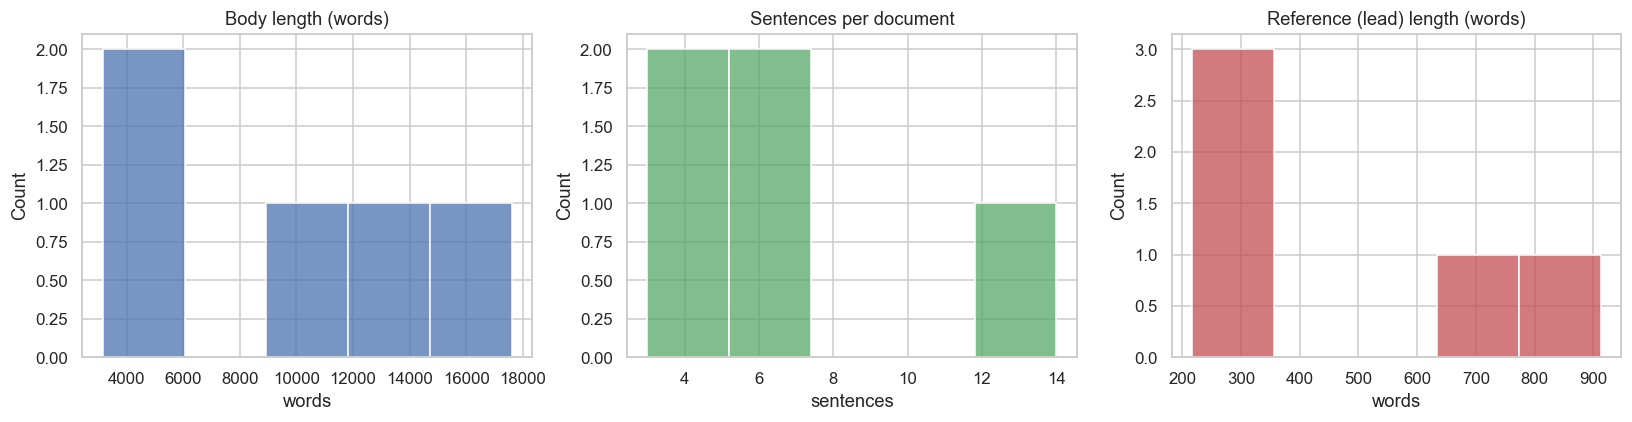

       n_words_body  n_sentences_body  n_words_reference
count           5.0               5.0                5.0
mean         9978.4               6.8              485.6
std          5788.5               4.5              310.6
min          3160.0               3.0              217.0
25%          5756.0               3.0              258.0
50%          9993.0               7.0              324.0
75%         13380.0               7.0              716.0
max         17603.0              14.0              913.0


In [7]:
print("Distributions")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_raw["n_words_body"], bins=min(10, len(df_raw)), ax=axes[0], color="#4C72B0")
axes[0].set_title("Body length (words)")
axes[0].set_xlabel("words")

sns.histplot(df_raw["n_sentences_body"], bins=min(10, len(df_raw)), ax=axes[1], color="#55A868")
axes[1].set_title("Sentences per document")
axes[1].set_xlabel("sentences")

sns.histplot(df_raw["n_words_reference"], bins=min(10, len(df_raw)), ax=axes[2], color="#C44E52")
axes[2].set_title("Reference (lead) length (words)")
axes[2].set_xlabel("words")

plt.tight_layout()
plt.show()

print(df_raw[["n_words_body", "n_sentences_body", "n_words_reference"]].describe().round(1))

## 05. Prethodna obrada teksta

Srpski jezik može biti napisan **ćirilicom** ili **latinicom** sa fiksnom, jedan-na-jedan korespondencijom slova između njih. Ovo je veoma važno za dalju obradu: ista reč napisana na dva pisma tretira se kao dva potpuno različita tokena bilo kojom metodom.

In [8]:
_CYR2LAT = {
    "А": "A", "Б": "B", "В": "V", "Г": "G", "Д": "D", "Ђ": "Đ", "Е": "E", "Ж": "Ž",
    "З": "Z", "И": "I", "Ј": "J", "К": "K", "Л": "L", "Љ": "Lj", "М": "M", "Н": "N",
    "Њ": "Nj", "О": "O", "П": "P", "Р": "R", "С": "S", "Т": "T", "Ћ": "Ć", "У": "U",
    "Ф": "F", "Х": "H", "Ц": "C", "Ч": "Č", "Џ": "Dž", "Ш": "Š",
    "а": "a", "б": "b", "в": "v", "г": "g", "д": "d", "ђ": "đ", "е": "e", "ж": "ž",
    "з": "z", "и": "i", "ј": "j", "к": "k", "л": "l", "љ": "lj", "м": "m", "н": "n",
    "њ": "nj", "о": "o", "п": "p", "р": "r", "с": "s", "т": "t", "ћ": "ć", "у": "u",
    "ф": "f", "х": "h", "ц": "c", "ч": "č", "џ": "dž", "ш": "š",
}

def cyr_to_lat(text):
    '''Transliterate Serbian Cyrillic to Latin. Non-Cyrillic characters pass through
    unchanged, so it is safe to call on already-Latin or mixed text.'''
    return "".join(_CYR2LAT.get(ch, ch) for ch in text)

# Serbian (Latin-script) stopwords -- common pronouns, conjunctions, prepositions
# and forms of "biti"/"jesam", used to down-weight function words in TF-IDF.
SR_STOPWORDS = set('''
a ako ali bi bih bila bili bilo bio bismo biste biti bez da do doduše dok
ga gde godine i ih im ima imam imao ipak iz ja je jedan jedna jedno jer jesam
jesi jesmo jeste jesu jesu li još kada kako kao koja koje koji kojima koju
li ma me mene meni mi mimo mnogo mogu moj moja moje mu na nad nakon nam nama
naš naša naše ne nego neka neki nekoliko nema neko nešto ni nije nikada nisam
nisi nismo niste nisu njega njegov njegova njegovo njemu njen njena njeno nju
njih njihov njihova njihovo o od ona onaj oni ono ova ovaj ove ovi ovo pa po
posle pod pored pre preko pri s sa se si smo su svaki sve svi svih svoj svoja
svoje svom ta tada taj tako te tebe tebi ti to toj tome tu u uz va vam vas
veoma više vrlo za zbog će ćemo ćete ću da li 
'''.split())

print("Cyrillic -> Latin sample:", cyr_to_lat("Београд је главни град Србије."))

Cyrillic -> Latin sample: Beograd je glavni grad Srbije.


In [9]:
def clean_text(text):
    text = cyr_to_lat(text)
    text = re.sub(r"http\S+", " ", text)          # stray URLs
    text = re.sub(r"\s+", " ", text)               # collapse whitespace
    text = text.strip()
    return text

def tokenize_words(text):
    text = text.lower()
    text = re.sub(r"[^a-zčćžšđ0-9\s]", " ", text)
    return [w for w in text.split() if w and w not in SR_STOPWORDS]

df = df_raw.copy()
df["body_clean"] = df["body"].apply(clean_text)
df["reference_clean"] = df["reference"].apply(clean_text)
df["sentences"] = df["body_clean"].apply(sentence_split)
df["n_sentences"] = df["sentences"].apply(len)

print("Example preprocessing on the first document:\n")
print("RAW   :", df.loc[0, "body"][:160], "...")
print("CLEAN :", df.loc[0, "body_clean"][:160], "...")
print("\nTokens (stopwords removed), first sentence:")
print(tokenize_words(df.loc[0, "sentences"][0]))

Example preprocessing on the first document:

RAW   : Општи проблем симулације (или стварања) интелигенције подељен је на подпроблеме. Они се састоје од одређених особина или способности које истраживачи очекују да ...
CLEAN : Opšti problem simulacije (ili stvaranja) inteligencije podeljen je na podprobleme. Oni se sastoje od određenih osobina ili sposobnosti koje istraživači očekuju  ...

Tokens (stopwords removed), first sentence:
['opšti', 'problem', 'simulacije', 'ili', 'stvaranja', 'inteligencije', 'podeljen', 'podprobleme']


## 06. Extractive summarization

### 6.1 TextRank

TextRank tretira svaku rečenicu kao čvor u grafu. Ivice su ponderisane sličnostima dve rečenice (ovde: kosinus sličnost njihovih TF-IDF vektora, nakon uklanjanja stop reči). Pokretanje PageRank-a na ovom grafu daje svakoj rečenici ocenu centralnosti; izbor rečenica sa najboljim rezultatom i njihovo vraćanje u prvobitni redosled daje ekstraktivan rezime koji teži da pokrije „najcentralnije“ ideje teksta.

In [10]:
def textrank_summarize(sentences, n_sentences=3):
    if len(sentences) <= n_sentences:
        return " ".join(sentences)

    corpus = [" ".join(tokenize_words(s)) for s in sentences]
    if all(len(c) == 0 for c in corpus):
        return " ".join(sentences[:n_sentences])

    vectorizer = TfidfVectorizer()
    try:
        tfidf = vectorizer.fit_transform(corpus)
    except ValueError:
        # e.g. every sentence became empty after stopword removal
        return " ".join(sentences[:n_sentences])

    sim_matrix = cosine_similarity(tfidf)
    np.fill_diagonal(sim_matrix, 0)

    graph = nx.from_numpy_array(sim_matrix)
    try:
        scores = nx.pagerank(graph, max_iter=200)
    except nx.PowerIterationFailedConvergence:
        scores = {i: 1.0 for i in range(len(sentences))}

    ranked_idx = sorted(scores, key=scores.get, reverse=True)[:n_sentences]
    ranked_idx.sort()  # restore original reading order
    return " ".join(sentences[i] for i in ranked_idx)

def n_summary_sentences(n_source_sentences):
    '''Roughly 30 percent of the source, at least 2 and at most 5 sentences.'''
    return int(np.clip(round(n_source_sentences * 0.3), 2, 5))

df["textrank_summary"] = df.apply(
    lambda r: textrank_summarize(r["sentences"], n_summary_sentences(r["n_sentences"])),
    axis=1,
)

print("TextRank summary of the first document:\n")
print(textwrap.fill(df.loc[0, "textrank_summary"], 100))

TextRank summary of the first document:

Kurs odluka može da bude proračunat (npr. iteracijom ), može biti heurističke prirode ili se može
naučiti. [ 45 ] Teorija igara opisuje racionalno ponašanje više agenata u interakciji i koristi se u
VI programima koji donose odluke koje uključuju druge agente. [ 46 ] Postoji više različitih oblika
učenja koji su primenjeni na oblast veštačke inteligencije. Okvir veštačke inteligencije kao što je
Pazite i postupajte okvir koji sadrži SUM vrednosti – koji je razvio Alan Tjuringov institut testira
projekte u četiri glavne oblasti: [ 250 ] [ 251 ] Ostali napreci u etičkim okvirima uključuju one o
kojima je odlučeno tokom Asilomar konferencije, Montrealsku deklaraciju za odgovornu veštačku
inteligenciju i inicijativu IEEE za etiku autonomnih sistema, između ostalog; [ 252 ] međutim, ovi
principi ne prolaze bez kritike, posebno u pogledu ljudski odabranih doprinosa ovim okvirima. [ 253
] Promovisanje blagostanja ljudi i zajednica na koje ove tehnologi

In [11]:
print("TextRank summary of the second document:\n")
print(textwrap.fill(df.loc[1, "textrank_summary"], 100))

TextRank summary of the second document:

Tesli je dat ovaj zadatak i on je boravio u Strazburu od 14. oktobra 1883. do 24. februara 1884 .
godine. [ 16 ] Tesla ovde potpisuje prvi poslovni ugovor u vezi realizacije prvog indukcionog
motora, tako je krajem 1883. godine u Strazburu nastao prvi indukcioni motor koji koristi princip
obrtnog magnetskog polja naizmeničnih struja. Tesla u Njujorku osniva svoju kompaniju, Tesla
električno osvetljenje i proizvodnja (Tesla Electric Light & Manufacturing). [ 5 ] [ 29 ] Prvobitni
osnivači se nisu složili sa Teslom oko njegovih planova za uvođenje motora na naizmeničnu struju i
na kraju je ostao bez finansijera i kompanije. Već 15. marta osniva kompaniju pod imenom „Nikola
Tesla” i nastavlja rad. I pored prodaje patenata u oblasti naizmeničnih struja, Tesla umire
siromašan i u dugovima. Takođe je utvrđeno da je Tesla imao 162 analoga ovih patenata uključujući tu
i dopunske i reizdate patente, što znači da je za svoje pronalaske Tesla dobio ukupno 

In [12]:
print("TextRank summary of the third document:\n")
print(textwrap.fill(df.loc[2, "textrank_summary"], 100))

TextRank summary of the third document:

Planine Srbije se dele na: Najviši vrhovi Srbije su: Panonska nizija predstavlja veoma značajnu
oblast Srbije. Delovi teritorije današnje Srbije su bili u sastavu Osmanskog carstva u periodu od 15
. do početka 20. veka . Srbija je izabrana da bude zemlja domaćin specijalizovane svetske izložbe
Expo 2027 . [ 73 ] [ 74 ] Prema popisu iz 2022. bilo je 6.647.003 stanovnika u Vojvodini i
centralnoj Srbiji , dok je na Kosovu i Metohiji održan zaseban popis iz 2024. koji je zabeležio
1.586.659 stanovnika. [ v ] Stopa ukupnog fertiliteta 2023. je iznosila 1,62 dece po ženi. [ 75 ]
Očekivani životni vek pri rođenju u Srbiji iznosi je 74,8 godine (muškarci 72,3; žene 77,5). [ 76 ]
Većinu stanovništva čine Srbi , dok je Srbija prepoznatljiva kao jedna od evropskih država sa
najvećim brojem registrovanih nacionalnih manjina , u čemu prednjače njene autonomne pokrajine . [
77 ] [ 78 ] [ 79 ] Tokom 1990-ih, usled raspada Jugoslavije a potom i ratova u Jugosla

In [13]:
print("TextRank summary of the fourth document:\n")
print(textwrap.fill(df.loc[3, "textrank_summary"], 100))

TextRank summary of the fourth document:

Brz razvoj Interneta je pomogla mogućnost TCP/IP -a (Internet protokola) da radi preko već
postojećih mreža i komunikacija (kao što su telefonske žice itd). Najpoznatije usluge za na
Internetu su: Mnogi ljudi sinonimno koriste termine Internet i World Wide Web , ili samo Web , mada
ta dva termina nisu sinonimi. Voice-over- Internet Protocol - protokol za prenos glasa preko
interneta. Korist od korišćenja Internata za prenos glasa je da VoIP može da bude besplatan ili
znatno jeftiniji od tradicionalnih telefonskih poziva, posebno na dugim rastojanjima i za korisnike
kojima je uvek dostupna internet konekcija kao što je kablovski ili ADSL priključak. To znači da se
uređaj koji je povezan sa Internetom, kao što je računar, može koristiti za pristup onlajn medijima
na skoro isti način kao što je ranije bilo moguće samo sa televizorom ili radio prijemnikom.


In [14]:
print("TextRank summary of the fifth document:\n")
print(textwrap.fill(df.loc[4, "textrank_summary"], 100))

TextRank summary of the fifth document:

Dana 7. novembra 1944. iznad Niša dogodio se najveći vazdušni saveznički sukob . [ 67 ] Niš je
postao centar Niškog regiona 1975, a od 1992 . i Nišavskog upravnog okruga . [ 3 ] U prvoj polovini
devedesetih godina 20. veka Niš je smatran za jako uporište SPS -a i zato je često nazivan „crveni
grad”. [ 68 ] Međutim, 1996 . godine, u Nišu, na lokalnim izborima, pobedila je Koalicija Zajedno ,
a gradonačelnik je postao Zoran Živković , koji je nešto kasnije postao i premijer Srbije. Naredbom
Vrhovne komande srpske vojske, samo nedelju dana nakon oslobođenja Niša, na predlog načelnika
saniteta dr Vladana Đorđevića , formira se, 10. januara (po starom kalendaru) 1878. godine, od tada
postojećih turskih bolnica u Nišu, Velika niška vojna bolnica za 1.000 bolesnika i ranjenika. Vojna
bolnica u Nišu postaje najveći epidemiološki centar u Srbiji. Preteča sadašnjeg Kliničkog centra i
prva civilna zdravstvena ustanova u Nišu, posle oslobođenja grada od Tur

## 07. Transformer model

### 7.1 Učitavanje modela

`csebuetnlp/mT5_multilingual_XLSum` je mT5 model fino podešen na skupu podataka XL-Sum,
koji pokriva 45 jezika, uključujući i srpski. To je najbliža stvar
„gotovom“ apstraktnom rezimizatoru za ovaj jezik.

### 7.2 Tokenizacija

Modelov sopstveni `AutoTokenizer` obrađuje tokenizaciju podreči i automatski skraćuje ulaze na maksimalnu dužinu sekvence (512 tokena).

### 7.3 Generacija

Sažeci se proizvode pomoću pretrage snopa, koja paralelno istražuje nekoliko kandidatskih sažetaka i zadržava onaj sa najvišim rezultatom.

In [15]:
TRANSFORMER_MODEL_NAME = "csebuetnlp/mT5_multilingual_XLSum"
_transformer_tokenizer = None
_transformer_model = None

if HAVE_TORCH:
    try:
        # use_fast=False: this model's tokenizer is a plain SentencePiece model.
        # Building the *fast* (Rust) version of it requires the `protobuf` package
        # at conversion time; when protobuf is missing/mismatched, transformers
        # silently tries a broken fallback path ("TikToken extractor") that fails
        # to parse the binary .model file. use_fast=False sidesteps all of that by
        # loading the plain-Python tokenizer, which only needs `sentencepiece`
        # (already installed) and is plenty fast for the batch sizes used here.
        _transformer_tokenizer = AutoTokenizer.from_pretrained(
            TRANSFORMER_MODEL_NAME, use_fast=False
        )
        _transformer_model = AutoModelForSeq2SeqLM.from_pretrained(TRANSFORMER_MODEL_NAME)
        print(f"Loaded {TRANSFORMER_MODEL_NAME}.")
    except Exception as exc:
        print(f"[warn] could not download/load '{TRANSFORMER_MODEL_NAME}' ({exc}) "
              "-> the Transformer method will use its fallback path.")
else:
    print("[warn] no PyTorch backend -> the Transformer method will use its fallback path.")

Loading weights: 100%|██████████| 284/284 [00:00<00:00, 39329.82it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Loaded csebuetnlp/mT5_multilingual_XLSum.


In [16]:
def transformer_summarize(text, max_input_tokens=512, max_output_tokens=84):
    if _transformer_model is None or _transformer_tokenizer is None:
        # Fallback: first three sentences, clearly labelled downstream.
        return None

    inputs = _transformer_tokenizer(
        [text],
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=max_input_tokens,
    )
    output_ids = _transformer_model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        num_beams=4,
        length_penalty=1.0,
        max_length=max_output_tokens,
        min_length=16,
        no_repeat_ngram_size=3,
    )[0]
    summary = _transformer_tokenizer.decode(
        output_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True
    )
    return summary

# Smoke-test on the first document so any problem surfaces immediately.
_test0 = transformer_summarize(df.loc[0, "body_clean"])
print("Transformer output available:" , _test0 is not None)
if _test0:
    print(textwrap.fill(_test0, 100))

Transformer output available: True
Veštačka inteligencija je jedna od najvećih tehnologija na svetu, a to je i jedna od ključnih
elemenata ove tehnologije.


In [17]:
_test1 = transformer_summarize(df.loc[1, "body_clean"])
print("Transformer output available:" , _test1 is not None)
if _test1:
    print(textwrap.fill(_test1, 100))

Transformer output available: True
Tesla, dete od petoro dece Milutina i majke Georgine, rođen je u Hrvatskoj.


In [18]:
_test2 = transformer_summarize(df.loc[2, "body_clean"])
print("Transformer output available:" , _test2 is not None)
if _test2:
    print(textwrap.fill(_test2, 100))

Transformer output available: True
Upozorenje: Ovaj članak sadrži uznemirujuće podatke.


In [19]:
_test3 = transformer_summarize(df.loc[3, "body_clean"])
print("Transformer output available:" , _test3 is not None)
if _test3:
    print(textwrap.fill(_test3, 100))

Transformer output available: True
Internet je proslavio više od 50 godina, ali jedan od najvećih otkrića koje su obeležili razvoj
komunikacije i komandne mreže u istoriji nije mogao da se složiti.


In [20]:
_test4 = transformer_summarize(df.loc[4, "body_clean"])
print("Transformer output available:" , _test4 is not None)
if _test4:
    print(textwrap.fill(_test4, 100))

Transformer output available: True
[ 1 ] Niša je jedan od najvećih grada u Srbiji.


## 08. LLM model

Treći metod podstiče model opšte namene prilagođen instrukcijama, `llama3.1:8b`
koji se lokalno služi preko Ollama-e sa eksplicitnom srpskom instrukcijom koja traži
kratak, veran rezime. Za razliku od gore navedenog transformera, ovaj model nikada nije
posebno fino podešen za rezime; zadatak je u potpunosti definisan kroz
prompt.

In [21]:
OLLAMA_MODEL = "llama3.1:8b"

LLM_PROMPT_TEMPLATE = (
    "Sažmi sledeći tekst na srpskom jeziku u najviše 4 rečenice. "
    "Piši isključivo na srpskom, jasno i verno originalu, bez dodavanja "
    "informacija kojih nema u tekstu.\n\nTekst:\n{text}\n\nSažetak:"
)

def llm_summarize(text, model=OLLAMA_MODEL, timeout=30):
    if not HAVE_OLLAMA_LIB:
        return None
    try:
        response = ollama.chat(
            model=model,
            messages=[{"role": "user", "content": LLM_PROMPT_TEMPLATE.format(text=text)}],
            options={"temperature": 0.2},
        )
        return response["message"]["content"].strip()
    except Exception as exc:
        print(f"[warn] Ollama call failed ({type(exc).__name__}: {exc}) "
              "-> the LLM method will use its fallback path for this document.")
        return None

_test_llm0 = llm_summarize(df.loc[0, "body_clean"])
print("LLM output available:", _test_llm0 is not None)
if _test_llm0:
    print(textwrap.fill(_test_llm0, 100))

LLM output available: True
Veštačka inteligencija je oblast nauke koja se bavi razvojem inteligentnih sistema koji mogu da
izvršavaju zadatake koji su obično rezervisani za ljude. Ova oblast je bila predmetom interesovanja
filozofa, naučnika i pisaca tokom istorije. Veštačka inteligencija se može definisati kao sposobnost
sistema da razmišlja, učuje i prilagođava se novim situacijama. Ova oblast je bila predmetom
interesovanja filozofa, naučnika i pisaca tokom istorije. Veštačka inteligencija se može koristiti
za različite svrhe, kao što je poboljšanje života ljudi, poboljšanje procesa, poboljšanje
bezbednosti i poboljšanje ekonomije. Međutim, veštačka inteligencija takođe predstavlja neke rizike,
kao što je mogućnost da sistemi veštačke inteligencije postanu prevladavajući nad ljudima i da
postanu pretnja za ljudsku egzistenciju.


In [22]:
_test_llm1 = llm_summarize(df.loc[1, "body_clean"])
print("LLM output available:", _test_llm1 is not None)
if _test_llm1:
    print(textwrap.fill(_test_llm1, 100))

LLM output available: True
Nikola Tesla je bio srpski inženjer i izumitelj koji je radio u SAD-u. On je bio jedan od prvih koji
je razumeo značaj električne energije i razvio je tehnike za njeno prenos. Tesla je imao više od 700
zaštićenih patenata i inovacija i njegovo ime je uvedeno u Dom slavnih pronalazača Amerike. On je
osmislio električni asinhroni motor i razvio je tehnike za prenos električne energije naizmeničnom
strujom. Tesla je takođe radio na daljinskim upravljanjima i razvio je Teslinu bobinu, koji je bio
prvi projektovani odašiljač talasa. On je imao ideju da će se jednoga dana bežičnom telegrafijom
upravljati vozilima bez posade udaljenim stotinama kilometara. Tesla je takođe bio društveno aktivan
i poznato je da je jedno vreme čitao o Vedskoj filozofiji.


In [23]:
_test_llm2 = llm_summarize(df.loc[2, "body_clean"])
print("LLM output available:", _test_llm2 is not None)
if _test_llm2:
    print(textwrap.fill(_test_llm2, 100))

LLM output available: True
Srbija je osvojila 14 olimpijskih medalja, od čega 5 zlatnih. Najuspešniji sportisti su Milica
Mandić, Davor Štefanek, Jovana Preković, Nađa Higl, Zorana Arunović, Nebojša Grujić, Marko
Novaković, Milenko Zorić, Marko Tomićević, Nemanja Majdov, Vanja Stanković, Ivana Španović, Viktor
Nemeš, Mate Nemeš, Ali Arsalan, Sebastijan Nađ i Zurab Datunašvili.


In [24]:
_test_llm3 = llm_summarize(df.loc[3, "body_clean"])
print("LLM output available:", _test_llm3 is not None)
if _test_llm3:
    print(textwrap.fill(_test_llm3, 100))

LLM output available: True
Internet je globalna mreža računala povezanih preko komunikacionih linija. On omogućava komunikaciju
između korisnika, kao što su e-pošta, chat, video konferencije, itd. Internet se koristi za
različite svrhe, kao što su prodaja i kupovina, preuzimanje fajlova, streamanje medija, itd.


In [25]:
_test_llm4 = llm_summarize(df.loc[4, "body_clean"])
print("LLM output available:", _test_llm4 is not None)
if _test_llm4:
    print(textwrap.fill(_test_llm4, 100))

LLM output available: True
Grad Niš ima bogatu istoriju i kulturno-umetnički značaj. Grad je poznat po svom kompleksu tvrđava,
koji je jedan od najznačajnijih spomenika kulture u Srbiji. Niš je poznat po svom kulturnom i
umetničkom životu, sa brojnim kulturnim institucijama, kao što su Narodni muzej Niš, Muzej savremene
umetnosti Vojvodine, Muzej umetnosti Niš, Muzej vojne istorije Niš, Muzej železničke stanice Niš,
Muzej železničke stanice Niš, Muzej železničke stanice Niš, Muzej železničke stanice Niš, Muzej
železničke stanice Niš, Muzej železničke stanice Niš, Muzej železničke stanice Niš, Muzej železničke
stanice Niš, Muzej železničke stanice Niš, Muzej železničke stanice Niš, Muzej železničke stanice
Niš, Muzej železničke stanice Niš, Muzej železničke stanice Niš, Muzej železničke stanice Niš, Muzej
železničke stanice Niš, Muzej železničke stanice Niš, Muzej železničke stanice Niš, Muzej železničke
stanice Niš, Muzej železničke stanice Niš, Muzej železničke stanice Niš, Muzej žele

## 09. Generisanje svih rezimea

Svaka od tri metode se sada izvršava nad svakim dokumentom u korpusu, sa vremenom izvršavanja koje se beleži po pozivu.

In [26]:
METHODS = ["textrank", "transformer", "llm"]

def naive_lead_fallback(sentences, n=3):
    return " ".join(sentences[:n])

records = []
for _, row in df.iterrows():
    n_sum = n_summary_sentences(row["n_sentences"])

    # --- TextRank (always genuine, no external dependency) -------------------
    t0 = time.perf_counter()
    tr_summary = textrank_summarize(row["sentences"], n_sum)
    records.append(dict(
        doc_id=row["doc_id"], title=row["title"], method="textrank",
        summary=tr_summary, runtime_sec=time.perf_counter() - t0, used_fallback=False,
    ))

    # --- Transformer -----------------------------------------------------------
    t0 = time.perf_counter()
    tf_summary = transformer_summarize(row["body_clean"])
    fell_back = tf_summary is None
    if fell_back:
        tf_summary = naive_lead_fallback(row["sentences"], n_sum)
    records.append(dict(
        doc_id=row["doc_id"], title=row["title"], method="transformer",
        summary=tf_summary, runtime_sec=time.perf_counter() - t0, used_fallback=fell_back,
    ))

    # --- LLM (Ollama) ------------------------------------------------------------
    t0 = time.perf_counter()
    llm_summary = llm_summarize(row["body_clean"])
    fell_back = llm_summary is None
    if fell_back:
        llm_summary = naive_lead_fallback(row["sentences"], n_sum)
    records.append(dict(
        doc_id=row["doc_id"], title=row["title"], method="llm",
        summary=llm_summary, runtime_sec=time.perf_counter() - t0, used_fallback=fell_back,
    ))

results = pd.DataFrame(records)
results = results.merge(
    df[["doc_id", "reference_clean", "n_words_body", "n_sentences"]],
    on="doc_id", how="left",
)
results["n_words_summary"] = results["summary"].apply(word_count)

print(f"Generated {len(results)} summaries "
      f"({len(df)} documents x {len(METHODS)} methods).")
print("\nFallback usage by method:")
print(results.groupby("method")["used_fallback"].mean().rename("fraction_fallback"))
results.head(15)

Generated 15 summaries (5 documents x 3 methods).

Fallback usage by method:
method
llm            0.0
textrank       0.0
transformer    0.0
Name: fraction_fallback, dtype: float64


,doc_id,title,method,summary,runtime_sec,used_fallback,reference_clean,n_words_body,n_sentences,n_words_summary
0,doc_00,Вештачка интелигенција,textrank,Kurs odluka može da bude proračunat (npr. iter...,0.034506,False,Veštačka inteligencija ( engl. artificial inte...,13380,303,862
1,doc_00,Вештачка интелигенција,transformer,Veštačka inteligencija je jedna od najvećih te...,3.244153,False,Veštačka inteligencija ( engl. artificial inte...,13380,303,19
2,doc_00,Вештачка интелигенција,llm,Veštačka inteligencija je oblast nauke koja se...,1.969699,False,Veštačka inteligencija ( engl. artificial inte...,13380,303,97
3,doc_01,Никола Тесла,textrank,Tesli je dat ovaj zadatak i on je boravio u St...,0.014118,False,"Nikola Tesla ( Smiljan , 10. jul 1856 — Njujor...",5756,254,162
4,doc_01,Никола Тесла,transformer,"Tesla, dete od petoro dece Milutina i majke Ge...",3.584740,False,"Nikola Tesla ( Smiljan , 10. jul 1856 — Njujor...",5756,254,13
5,doc_01,Никола Тесла,llm,Nikola Tesla je bio srpski inženjer i fizičar ...,1.428173,False,"Nikola Tesla ( Smiljan , 10. jul 1856 — Njujor...",5756,254,83
6,doc_02,Србија,textrank,Planine Srbije se dele na: Najviši vrhovi Srbi...,0.054588,False,"Srbija , zvanično Republika Srbija , država je...",17603,577,261
7,doc_02,Србија,transformer,Upozorenje: Ovaj članak sadrži uznemirujuće po...,1.547856,False,"Srbija , zvanično Republika Srbija , država je...",17603,577,6
8,doc_02,Србија,llm,Srbija je osvojila 30 medalja na Olimpijskim i...,2.885411,False,"Srbija , zvanično Republika Srbija , država je...",17603,577,143
9,doc_03,Интернет,textrank,Brz razvoj Interneta je pomogla mogućnost TCP/...,0.007344,False,Internet je svetski sistem povezanih računarsk...,3160,140,138


## 10. Evaluacija

Svaki generisani rezime se boduje u odnosu na uvodni pasus Vikipedije dokumenta
(`reference_clean`) pomoću **ROUGE-1**, **ROUGE-2** i **ROUGE-L** F-mera —
standardnih metrika preklapanja n-grama za sumiranje. Dodate su još dve dijagnostike bez referenci
jer sam ROUGE malo govori o *kako* metod
sumira:

* **compression ratio** — dužina rezimea / dužina izvora (manje = više kompresovano),
* **novel-unigram ratio** — deo reči u rezimeu koje se **ne** pojavljuju u izvornom tekstu (0 za čisto ekstraktivnu metodu po konstrukciji; veće vrednosti ukazuju na više parafraziranja, a takođe i više prostora za model da uvede nepodržan sadržaj).

In [27]:
def compute_rouge(reference, hypothesis):
    if not HAVE_ROUGE or not reference.strip() or not hypothesis.strip():
        return dict(rouge1=np.nan, rouge2=np.nan, rougeL=np.nan)
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)
    scores = scorer.score(reference, hypothesis)
    return {k: v.fmeasure for k, v in scores.items()}

def novel_unigram_ratio(source, summary):
    source_words = set(tokenize_words(source))
    summary_words = tokenize_words(summary)
    if not summary_words:
        return np.nan
    novel = [w for w in summary_words if w not in source_words]
    return len(novel) / len(summary_words)

rouge_rows = results.apply(
    lambda r: compute_rouge(r["reference_clean"], r["summary"]), axis=1, result_type="expand"
)
results = pd.concat([results, rouge_rows], axis=1)

results["compression_ratio"] = results["n_words_summary"] / results["n_words_body"]
results["novel_unigram_ratio"] = results.apply(
    lambda r: novel_unigram_ratio(
        df.loc[df["doc_id"] == r["doc_id"], "body_clean"].iloc[0], r["summary"]
    ),
    axis=1,
)

results[["doc_id", "method", "rouge1", "rouge2", "rougeL",
         "compression_ratio", "novel_unigram_ratio"]].round(3)

,doc_id,method,rouge1,rouge2,rougeL,compression_ratio,novel_unigram_ratio
0,doc_00,textrank,0.402,0.117,0.153,0.064,0.000
1,doc_00,transformer,0.033,0.008,0.029,0.001,0.250
2,doc_00,llm,0.140,0.049,0.086,0.007,0.212
3,doc_01,textrank,0.283,0.047,0.136,0.028,0.000
4,doc_01,transformer,0.044,0.009,0.044,0.002,0.000
5,doc_01,llm,0.267,0.039,0.182,0.014,0.532
6,doc_02,textrank,0.219,0.032,0.097,0.015,0.000
7,doc_02,transformer,0.006,0.000,0.006,0.000,0.600
8,doc_02,llm,0.092,0.005,0.068,0.008,0.000
9,doc_03,textrank,0.258,0.044,0.118,0.044,0.000


## 11. Analiza grešaka

Agregirane metrike skrivaju pojedinačne neuspehe. Ovaj odeljak traži tri konkretna
načina neuspeha: rezimee koji su postigli neobično niske ocene, rezimee koji se ponavljaju
(poznati način neuspeha apstraktnog modela) i uporedno kvalitativno poređenje
jednog dokumenta.

In [28]:
def has_repeated_ngram(text, n=4):
    words = tokenize_words(text)
    seen = set()
    for i in range(len(words) - n + 1):
        gram = tuple(words[i:i + n])
        if gram in seen:
            return True
        seen.add(gram)
    return False

results["repeats_ngram"] = results["summary"].apply(has_repeated_ngram)
results["is_empty"] = results["summary"].str.strip().eq("")

low_threshold = results["rouge1"].quantile(0.25)
worst = results.sort_values("rouge1").head(5)

print(f"25th percentile of ROUGE-1 across all summaries: {low_threshold:.3f}")
print(f"Summaries with a repeated 4-gram: {int(results['repeats_ngram'].sum())} / {len(results)}")
print(f"Empty summaries: {int(results['is_empty'].sum())} / {len(results)}")
print("\nFive lowest-scoring (method, document) pairs:")
worst[["doc_id", "title", "method", "rouge1", "used_fallback"]]

25th percentile of ROUGE-1 across all summaries: 0.071
Summaries with a repeated 4-gram: 2 / 15
Empty summaries: 0 / 15

Five lowest-scoring (method, document) pairs:


,doc_id,title,method,rouge1,used_fallback
7,doc_02,Србија,transformer,0.005882,False
1,doc_00,Вештачка интелигенција,transformer,0.032536,False
4,doc_01,Никола Тесла,transformer,0.043860,False
13,doc_04,Ниш,transformer,0.050139,False
8,doc_02,Србија,llm,0.092233,False


In [29]:
# Qualitative side-by-side comparison on a single document.
example_doc = df.loc[0, "doc_id"]
example_rows = results[results["doc_id"] == example_doc]

print(f"Document: {df.loc[df.doc_id == example_doc, 'title'].iloc[0]}\n")
print("REFERENCE (lead paragraph):")
print(textwrap.fill(df.loc[df.doc_id == example_doc, "reference_clean"].iloc[0], 100))
for _, r in example_rows.iterrows():
    tag = " [FALLBACK]" if r["used_fallback"] else ""
    print(f"\n{r['method'].upper()}{tag} (ROUGE-1={r['rouge1']:.3f}):")
    print(textwrap.fill(r["summary"], 100))

Document: Вештачка интелигенција

REFERENCE (lead paragraph):
Veštačka inteligencija ( engl. artificial intelligence , AI) je podoblast računarstva koja razvija i
proučava inteligentne mašine. [ 1 ] [ 2 ] Veštačka inteligencija je inteligencija mašina ili
softvera, za razliku od inteligencije živih bića, prvenstveno ljudi . Cilj istraživanja veštačke
inteligencije je razvijanje programa ( softvera ), koji će računarima omogućiti da se ponašaju na
način koji bi se mogao okarakterisati inteligentnim. Prva istraživanja se vežu za same korene
računarstva. Ideja o stvaranju mašina koje će biti sposobne da obavljaju različite zadatke
inteligentno, bila je centralna preokupacija naučnika oblasti računarstva koji su se opredelili za
istraživanje veštačke inteligencije, tokom cele druge polovine 20. veka . Savremena istraživanja u
veštačkoj inteligenciji su orijentisana na ekspertske i prevodilačke sisteme u ograničenim domenima,
prepoznavanje prirodnog govora i pisanog teksta, automatske dokaz

In [30]:
example_doc = df.loc[1, "doc_id"]
example_rows = results[results["doc_id"] == example_doc]

print(f"Document: {df.loc[df.doc_id == example_doc, 'title'].iloc[0]}\n")
print("REFERENCE (lead paragraph):")
print(textwrap.fill(df.loc[df.doc_id == example_doc, "reference_clean"].iloc[0], 100))
for _, r in example_rows.iterrows():
    tag = " [FALLBACK]" if r["used_fallback"] else ""
    print(f"\n{r['method'].upper()}{tag} (ROUGE-1={r['rouge1']:.3f}):")
    print(textwrap.fill(r["summary"], 100))

Document: Никола Тесла

REFERENCE (lead paragraph):
Nikola Tesla ( Smiljan , 10. jul 1856 — Njujork , 7. januar 1943 ) bio je srpski i američki [ 1 ] [
2 ] [ 3 ] pronalazač , inženjer elektrotehnike i mašinstva i futurista . Tesla je najpoznatiji po
svom doprinosu u projektovanju modernog sistema napajanja naizmeničnom strujom . Najznačajniji
Teslini pronalasci su polifazni sistem , obrtno magnetsko polje , asinhroni motor , sinhroni motor i
Teslin transformator . Takođe, otkrio je jedan od načina za generisanje visokofrekventne struje, dao
je značajan doprinos u prenosu i modulaciji radio-signala, a ostali su zapaženi i njegovi radovi u
oblasti rendgenskih zraka . Njegov sistem naizmeničnih struja je omogućio znatno lakši i efikasniji
prenos električne energije na daljinu. Bio je ključni čovek u izgradnji prve hidrocentrale na
Nijagarinim vodopadima . Preminuo je u svojoj 87. godini, siromašan i zaboravljen. Jedini je Srbin
po kome je nazvana jedna međunarodna jedinica mere , jedinica

In [31]:
example_doc = df.loc[2, "doc_id"]
example_rows = results[results["doc_id"] == example_doc]

print(f"Document: {df.loc[df.doc_id == example_doc, 'title'].iloc[0]}\n")
print("REFERENCE (lead paragraph):")
print(textwrap.fill(df.loc[df.doc_id == example_doc, "reference_clean"].iloc[0], 100))
for _, r in example_rows.iterrows():
    tag = " [FALLBACK]" if r["used_fallback"] else ""
    print(f"\n{r['method'].upper()}{tag} (ROUGE-1={r['rouge1']:.3f}):")
    print(textwrap.fill(r["summary"], 100))

Document: Србија

REFERENCE (lead paragraph):
Srbija , zvanično Republika Srbija , država je u srednjoj i jugoistočnoj Evropi . [ 5 ] [ 6 ] Većim
delom zahvata Balkansko poluostrvo , a manjim Panonsku niziju . [ 7 ] Graniči se na severu sa
Mađarskom , na severoistoku sa Rumunijom , na istoku sa Bugarskom , na jugu sa Severnom Makedonijom
, na jugozapadu sa Albanijom i Crnom Gorom , a na zapadu sa Bosnom i Hercegovinom i Hrvatskom .
Broji oko šest miliona i sedamsto hiljada stanovnika. [ 8 ] Glavni i najveći grad je Beograd , koji
spada među najstarije i najveće gradove u jugoistočnoj Evropi. [ 6 ] [ 9 ] Zvanični jezik je srpski
, a zvanična valuta srpski dinar . Nakon naseljavanja Srba na Balkan tokom 6. i 7. veka, Srbi su u
ranom srednjem veku osnovali nekoliko država . Prvi po imenu poznati srpski vladar, bio je knez
Višeslav , koji je krajem 8. veka vladao u tadašnjoj Kneževini Srbiji . Pominje se u istoriografskom
delu „ O upravljanju carstvom ” ( lat. De Administrando Imperio ; DA

In [32]:
example_doc = df.loc[3, "doc_id"]
example_rows = results[results["doc_id"] == example_doc]

print(f"Document: {df.loc[df.doc_id == example_doc, 'title'].iloc[0]}\n")
print("REFERENCE (lead paragraph):")
print(textwrap.fill(df.loc[df.doc_id == example_doc, "reference_clean"].iloc[0], 100))
for _, r in example_rows.iterrows():
    tag = " [FALLBACK]" if r["used_fallback"] else ""
    print(f"\n{r['method'].upper()}{tag} (ROUGE-1={r['rouge1']:.3f}):")
    print(textwrap.fill(r["summary"], 100))

Document: Интернет

REFERENCE (lead paragraph):
Internet je svetski sistem povezanih računarskih mreža koji je transformisao način na koji
funkcionišu komunikacioni sistemi. Počeci interneta se vežu za stvaranje ARPANET -a 1969. godine,
mreže računara pod kontrolom Ministarstva odbrane SAD . Danas internet povezuje milijarde računara
širom sveta na jedan nehijerarhijski način. Internet je proizvod spoja medija, računara i
telekomunikacija . Međutim, internet nije samo proizvod tehnološkog napretka, nego takođe društvenih
i političkih procesa, uključujući naučnu zajednicu, politiku i vojsku. Od svojih korena kao jedno
neindustrijsko i neposlovno okruženje vezano za naučnu zajednicu, Internet se vrlo brzo proširio na
svet trgovine i poslovanja. Ipak, bilo je potrebno skoro 30 godina da se internet nametne kao
tehnološka inovacija koja konstantno transformiše društvo i ekonomiju. Internet je javno dostupna
globalna paketna mreža podataka koja povezuje računare i računarske mreže korišćenj

In [33]:
example_doc = df.loc[4, "doc_id"]
example_rows = results[results["doc_id"] == example_doc]

print(f"Document: {df.loc[df.doc_id == example_doc, 'title'].iloc[0]}\n")
print("REFERENCE (lead paragraph):")
print(textwrap.fill(df.loc[df.doc_id == example_doc, "reference_clean"].iloc[0], 100))
for _, r in example_rows.iterrows():
    tag = " [FALLBACK]" if r["used_fallback"] else ""
    print(f"\n{r['method'].upper()}{tag} (ROUGE-1={r['rouge1']:.3f}):")
    print(textwrap.fill(r["summary"], 100))

Document: Ниш

REFERENCE (lead paragraph):
Niš je gradsko naselje i sedište istoimene teritorijalne jedinice u Srbiji . Administrativni je
centar Nišavskog upravnog okruga i najveći grad južne Srbije . Prema popisu iz 2022. bilo je 182.797
stanovnika, pa je tako Niš treći grad po broju stanovnika u Srbiji (posle Beograda i Novog Sada ).
Nalazi se na reci Nišavi , nedaleko od njenog ušća u Južnu Moravu . Grad Niš zauzima površinu od oko
596,73 km 2 , uključujući Nišku Banju i 68 prigradskih naselja. Niš je bio administrativni, vojni i
trgovinski centar različitih država i carstava kojima je, tokom svoje duge istorije, pripadao. Na
prostoru današnjeg Niša, u antičkom gradu Naisu rođeni su rimski carevi Konstantin Veliki i
Konstancije III . [ 1 ] Geografski položaj Niša učinio ga je strateški važnim i time primamljivim
gradom za mnoge osvajače. Tokom istorije, teritorijom na kojoj se današnji grad nalazi prošli su
Dardanci , Tračani , Iliri , Kelti , Rimljani , Huni , Avari , a zatim i Vi

## 12. Poređenje modela

Metode se upoređuju na osnovu srednjih ROUGE rezultata i vremena izvršavanja, nakon čega sledi upareni
Vilkoksonov test označenih rangova na ROUGE-1 (upareni po dokumentu, pošto svaka metoda
sumira iste dokumente). Sa ovako malim korpusom, test je nedovoljno snažan
i uglavnom ilustruje tok rada — videti odeljak Diskusija.

In [34]:
summary_stats = results.groupby("method")[
    ["rouge1", "rouge2", "rougeL", "compression_ratio", "novel_unigram_ratio", "runtime_sec"]
].agg(["mean", "std"]).round(3)
summary_stats

rouge1        rouge2        rougeL        compression_ratio  \
              mean    std   mean    std   mean    std              mean   
method                                                                    
llm          0.147  0.071  0.023  0.021  0.093  0.052             0.011   
textrank     0.304  0.075  0.061  0.033  0.132  0.025             0.035   
transformer  0.049  0.039  0.011  0.011  0.040  0.028             0.003   

                   novel_unigram_ratio        runtime_sec         
               std                mean    std        mean    std  
method                                                            
llm          0.004               0.244  0.253       1.891  0.682  
textrank     0.020               0.000  0.000       0.028  0.018  
transformer  0.003               0.267  0.216       3.036  0.976

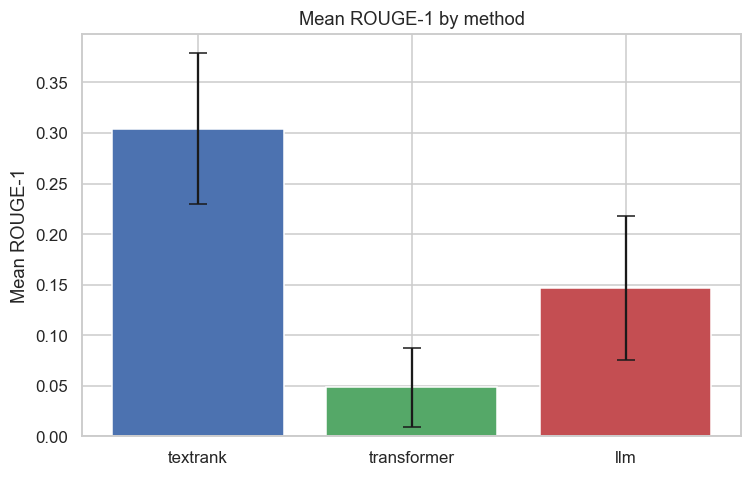

In [35]:
fig, ax = plt.subplots(figsize=(7, 4.5))
means = results.groupby("method")["rouge1"].mean()
stds = results.groupby("method")["rouge1"].std().fillna(0)
order = ["textrank", "transformer", "llm"]
ax.bar(order, means.reindex(order), yerr=stds.reindex(order), capsize=6,
       color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Mean ROUGE-1")
ax.set_title("Mean ROUGE-1 by method")
plt.tight_layout()
plt.show()

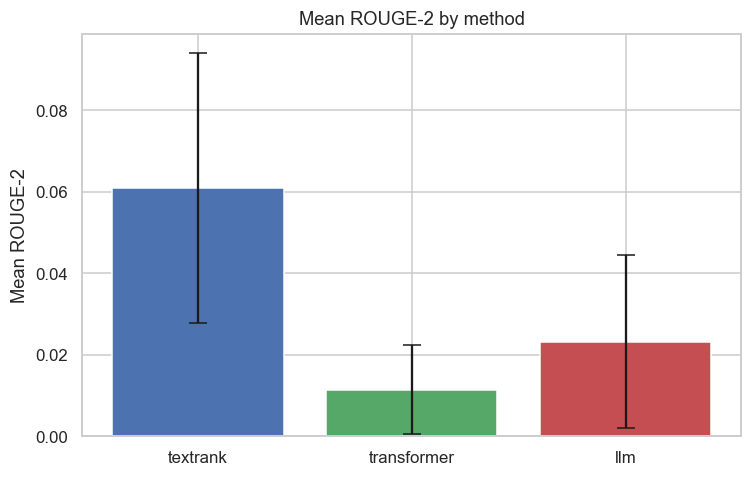

In [36]:
fig, ax = plt.subplots(figsize=(7, 4.5))
means = results.groupby("method")["rouge2"].mean()
stds = results.groupby("method")["rouge2"].std().fillna(0)
order = ["textrank", "transformer", "llm"]
ax.bar(order, means.reindex(order), yerr=stds.reindex(order), capsize=6,
       color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Mean ROUGE-2")
ax.set_title("Mean ROUGE-2 by method")
plt.tight_layout()
plt.show()

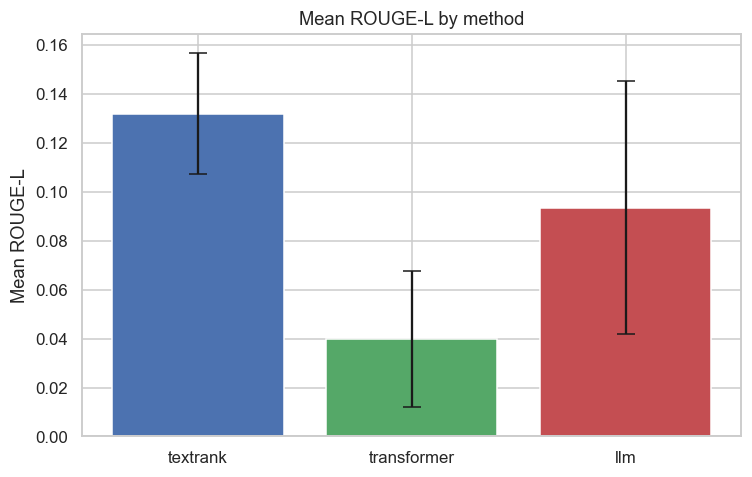

In [37]:
fig, ax = plt.subplots(figsize=(7, 4.5))
means = results.groupby("method")["rougeL"].mean()
stds = results.groupby("method")["rougeL"].std().fillna(0)
order = ["textrank", "transformer", "llm"]
ax.bar(order, means.reindex(order), yerr=stds.reindex(order), capsize=6,
       color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Mean ROUGE-L")
ax.set_title("Mean ROUGE-L by method")
plt.tight_layout()
plt.show()

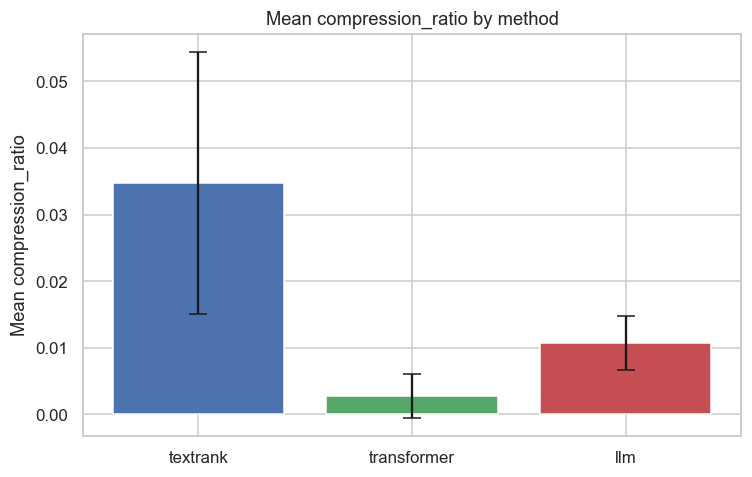

In [38]:
fig, ax = plt.subplots(figsize=(7, 4.5))
means = results.groupby("method")["compression_ratio"].mean()
stds = results.groupby("method")["compression_ratio"].std().fillna(0)
order = ["textrank", "transformer", "llm"]
ax.bar(order, means.reindex(order), yerr=stds.reindex(order), capsize=6,
       color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Mean compression_ratio")
ax.set_title("Mean compression_ratio by method")
plt.tight_layout()
plt.show()

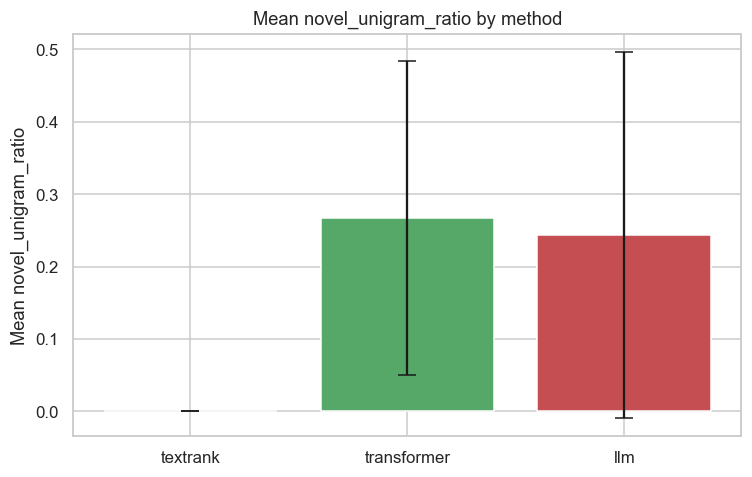

In [39]:
fig, ax = plt.subplots(figsize=(7, 4.5))
means = results.groupby("method")["novel_unigram_ratio"].mean()
stds = results.groupby("method")["novel_unigram_ratio"].std().fillna(0)
order = ["textrank", "transformer", "llm"]
ax.bar(order, means.reindex(order), yerr=stds.reindex(order), capsize=6,
       color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Mean novel_unigram_ratio")
ax.set_title("Mean novel_unigram_ratio by method")
plt.tight_layout()
plt.show()

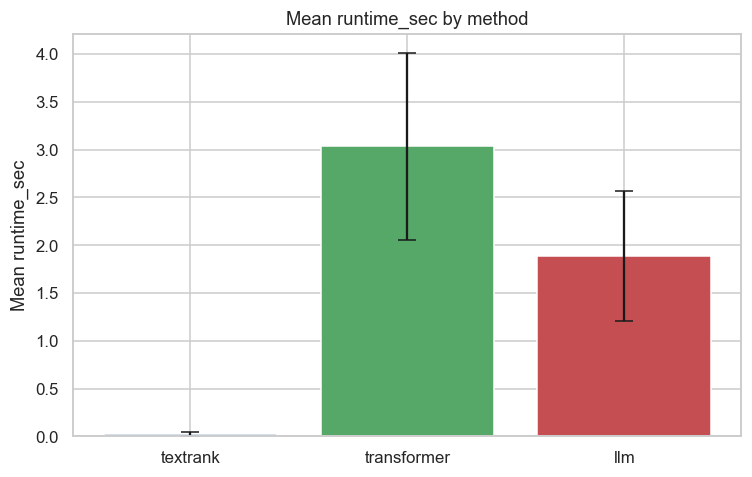

In [40]:
fig, ax = plt.subplots(figsize=(7, 4.5))
means = results.groupby("method")["runtime_sec"].mean()
stds = results.groupby("method")["runtime_sec"].std().fillna(0)
order = ["textrank", "transformer", "llm"]
ax.bar(order, means.reindex(order), yerr=stds.reindex(order), capsize=6,
       color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Mean runtime_sec")
ax.set_title("Mean runtime_sec by method")
plt.tight_layout()
plt.show()

## 13. Analiza vremena izvršavanja

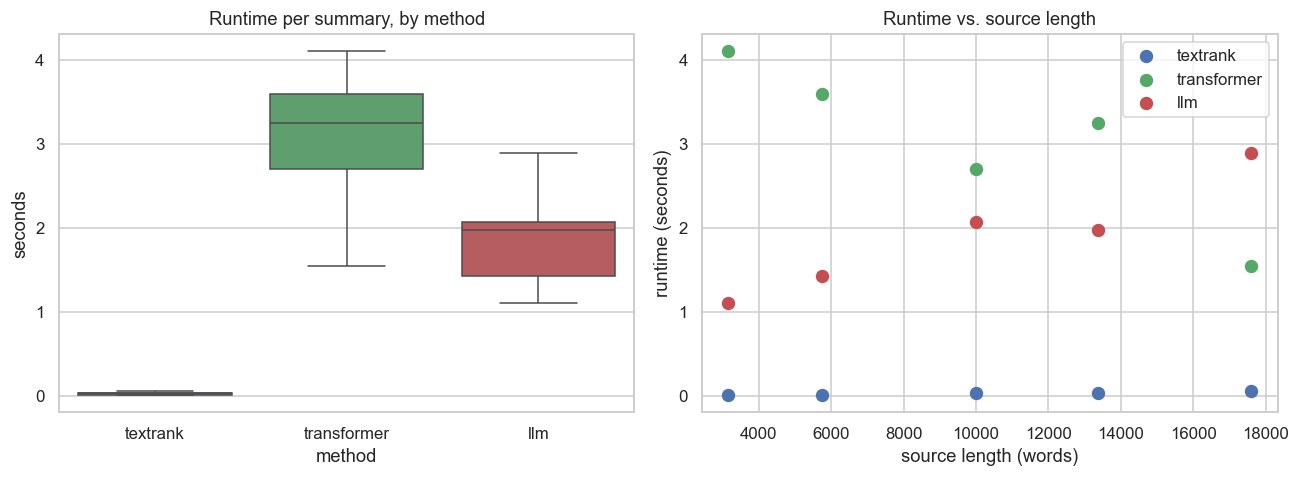

               mean     std     min     max
method                                     
llm          1.8906  0.6819  1.1036  2.8854
textrank     0.0277  0.0185  0.0073  0.0546
transformer  3.0360  0.9757  1.5479  4.1021


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=results, x="method", y="runtime_sec", order=order, ax=axes[0],
            palette=["#4C72B0", "#55A868", "#C44E52"])
axes[0].set_title("Runtime per summary, by method")
axes[0].set_ylabel("seconds")

for m, color in zip(order, ["#4C72B0", "#55A868", "#C44E52"]):
    sub = results[results["method"] == m]
    axes[1].scatter(sub["n_words_body"], sub["runtime_sec"], label=m, color=color, s=60)
axes[1].set_xlabel("source length (words)")
axes[1].set_ylabel("runtime (seconds)")
axes[1].set_title("Runtime vs. source length")
axes[1].legend()

plt.tight_layout()
plt.show()

print(results.groupby("method")["runtime_sec"].describe()[["mean", "std", "min", "max"]].round(4))

## 14. Vizuelizacija rezultata

Konsolidovani prikaz koji objedinjuje gore izračunate metrike: srednje ocene za
sve tri ROUGE varijante (kao toplotna mapa) i kompresija u odnosu na apstraktnost
(odnos kompresije u odnosu na odnos novel-unigram) kao rasejanje, gde bi se pravi
transformer/LLM rad vidljivo odvojio od TextRank-a (ekstraktivne metode su
konstrukcijom ograničene na odnos novel-unigram od 0).

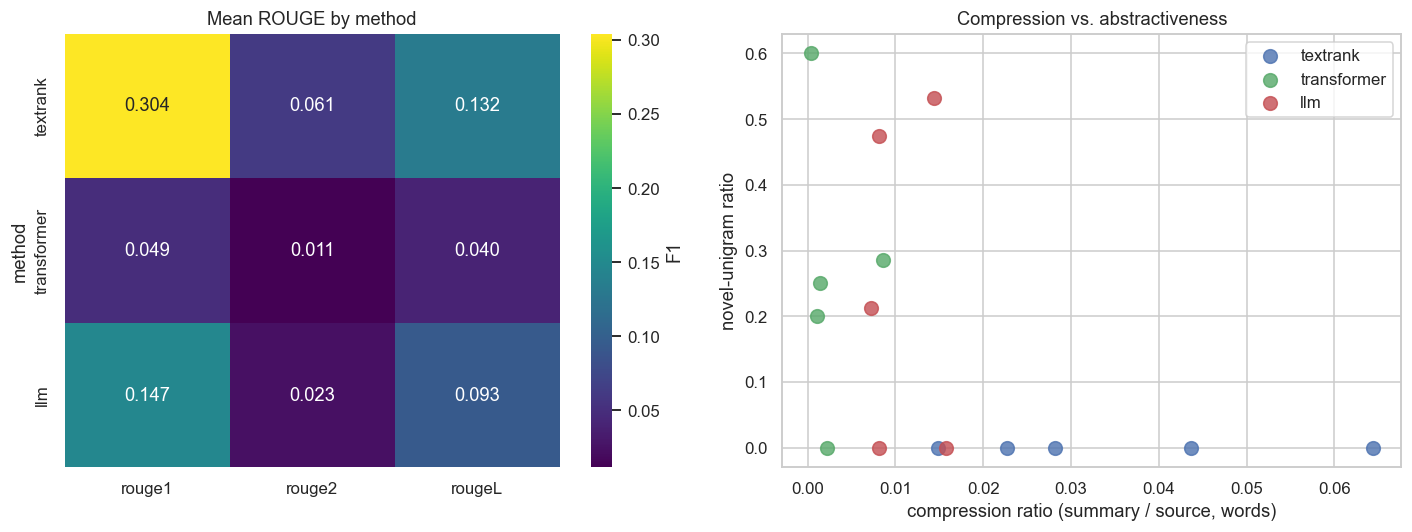

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

heat_data = results.groupby("method")[["rouge1", "rouge2", "rougeL"]].mean().reindex(order)
sns.heatmap(heat_data, annot=True, fmt=".3f", cmap="viridis", ax=axes[0], cbar_kws={"label": "F1"})
axes[0].set_title("Mean ROUGE by method")

for m, color in zip(order, ["#4C72B0", "#55A868", "#C44E52"]):
    sub = results[results["method"] == m]
    axes[1].scatter(sub["compression_ratio"], sub["novel_unigram_ratio"],
                     label=m, color=color, s=80, alpha=0.8)
axes[1].set_xlabel("compression ratio (summary / source, words)")
axes[1].set_ylabel("novel-unigram ratio")
axes[1].set_title("Compression vs. abstractiveness")
axes[1].legend()

plt.tight_layout()
plt.show()

## 15. Diskusija

**O samim metodama.** TextRank-u nisu potrebni podaci za obuku ili GPU i proizvodi
gramatički savršene (jer nisu modifikovane) srpske rečenice, ali može samo
rekombinovati postojeće rečenice, ne može kompresovati ideju koja je raširena na
nekoliko rečenica u jednu. mT5-XLSum transformer i podstaknuti LLM mogu, u
principu, slobodno parafrazirati i kompresovati.

**O evaluaciji.** Korišćenje uvodnog pasusa Vikipedije kao rezimea reference je
zgodna zamena bez troškova anotacije. Takođe pristrasno poređenje
ka ekstraktivnim rezultatima, jer sam uvodni pasus pišu ljudi
koji su izabrali specifične reči koje apstraktni model nema razloga da reprodukuje
tačno. ROUGE ovo pogoršava: nagrađuje tačno preklapanje n-grama i slep je za
parafraze, što je mnogo veći problem za srpski nego za engleski jezik upravo
zbog bogate morfologije jezika (npr. *grad*, *grada*, *gradu*, *gradom* su
četiri različite tokene za jednu lemu). Pravednije poređenje bi dodalo
metriku zasnovanu na ugrađivanju kao što je BERTScore sa enkoderom koji je svestan srpskog ili slovenskog jezika
(npr. BERTić / classla), ili lematizovati i referencu i hipotezu pre bodovanja.

**Na skupu podataka.** Pet kandidatskih stranica je mali korpus po bilo kom standardu.

## 16. Zaključak

Ova sveska je izgradila sveobuhvatni, reproduktivni cevovod za poređenje ekstraktivnog, transformerski zasnovanog i LLM zasnovanog sumiranja na srpskom veb tekstu: preuzimanje sa principijelnom konstrukcijom referenci-sumiranja (Vikipedijin uvod naspram tela), prethodna obrada specifična za srpski jezik (normalizacija skripte, prilagođena lista zaustavnih reči, razdvajanje rečenica bez zavisnosti), tri sumirača i višeugaona evaluacija (ROUGE, kompresija, apstraktnost, vreme izvršavanja, analiza grešaka, osetljivost na dužinu).

**Budući rad:**
* Značajno proširiti korpus i diverzifikovati izvore van Vikipedije (vesti, blogovi)
* Dodati metriku evaluacije koja je svesna srpskog jezika (BERTScore sa BERTić/classla, ili lematizovani ROUGE) da biste rešili problem morfologije.
* Isprobati odgovarajući srpski razdelnik/tokenizator rečenica (classla) umesto regularnih izraza heuristike koja se ovde koristi i razmisliti o finom podešavanju transformera na srpskim podacima umesto oslanjanja na višejezičnu kontrolnu tačku na 45 jezika.
* Izbor drugih modela LLM-ova.
